# 03 -- Attribution Model Comparison
**B2B Full-Funnel Attribution** | Meta DS V Portfolio

Compares all 6 attribution models to understand how channel credit changes
depending on modelling assumptions.

Models: First Touch | Last Touch | Linear | Time Decay | Position-Based | Data-Driven


In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = r"C:/Users/syeda/b2b-full-funnel-attribution"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import sqlite3
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from IPython.display import Image, display
import config

sns.set_theme(style="whitegrid")
os.makedirs("visuals", exist_ok=True)
conn = sqlite3.connect(config.DB_PATH)
print("Connected | working dir:", os.getcwd())


Connected | working dir: C:\Users\syeda\b2b-full-funnel-attribution


## 1. Run All 6 Attribution Models

In [2]:
from src.attribution_models import run_all_models, get_channel_comparison, model_agreement_score

results = run_all_models(conn)
print(f"Total records: {len(results):,}")
print(f"Models: {results['model'].unique().tolist()}")
print(f"Channels: {results['channel'].unique().tolist()}")


Total records: 60
Models: ['first_touch', 'last_touch', 'linear', 'time_decay', 'position_based', 'data_driven']
Channels: ['Content_Syndication', 'Direct', 'Email', 'Events', 'Organic_Search', 'Outbound_Sales', 'Paid_Search', 'Paid_Social', 'Partner', 'Webinar']


## 2. Time Decay Results -- Sorted by Revenue

In [3]:
td = (results[results["model"] == "time_decay"]
      .sort_values("attributed_revenue", ascending=False)
      .copy())
td["attributed_revenue_fmt"] = td["attributed_revenue"].apply(lambda x: f"${x:,.0f}")
print("=== Time Decay Attribution by Channel ===")
print(td[["channel", "attributed_revenue_fmt", "conversions"]].to_string(index=False))


=== Time Decay Attribution by Channel ===
            channel attributed_revenue_fmt  conversions
            Partner            $41,114,943         2582
              Email            $37,897,603         2524
        Paid_Search            $37,811,594         2540
        Paid_Social            $35,372,544         2476
             Events            $32,006,488         2429
     Organic_Search            $24,751,554         2245
             Direct            $24,577,992         2218
Content_Syndication            $16,732,314         1956
            Webinar            $16,056,003         1896
     Outbound_Sales            $10,622,251         1480


## 3. Grouped Bar Chart -- Channel x Model

In [4]:
model_order = ["first_touch","last_touch","linear","time_decay","position_based","data_driven"]
results["model"] = pd.Categorical(results["model"], categories=model_order, ordered=True)

fig = px.bar(
    results.sort_values(["channel","model"]),
    x="channel", y="attributed_revenue", color="model",
    barmode="group",
    title="Attributed Revenue by Channel & Model",
    labels={"attributed_revenue": "Attributed Revenue ($)", "channel": "Channel"},
    color_discrete_sequence=px.colors.qualitative.Set2,
    height=500,
)
fig.update_layout(
    xaxis_tickangle=-35,
    legend_title_text="Attribution Model",
    yaxis_tickformat="$,.0f",
)
fig.write_html("visuals/03_attribution_comparison.html")


## 4. Model Agreement Score

In [5]:
wide = get_channel_comparison(conn)
score = model_agreement_score(wide)
print(f"Model Agreement Score (top-3 channel consistency): {score:.1%}")
if score >= 0.8:
    print("  -> HIGH agreement. Any model is defensible.")
elif score >= 0.5:
    print("  -> MODERATE. Use time decay as default; supplement with position-based.")
else:
    print("  -> LOW agreement. Present 2-3 models to stakeholders.")


Model Agreement Score (top-3 channel consistency): 26.7%
  -> LOW agreement. Present 2-3 models to stakeholders.


## 5. Channels with Highest Cross-Model Variance

In [6]:
model_cols = [c for c in wide.columns if c != "channel"]
wide["variance"] = wide[model_cols].var(axis=1)
wide["std_dev"]  = wide[model_cols].std(axis=1)
wide["cv"]       = wide["std_dev"] / wide[model_cols].mean(axis=1)

top3_var = wide.nlargest(3, "variance")[["channel","variance","std_dev","cv"]]
top3_var.columns = ["channel","variance","std_dev","coeff_variation"]
print("=== Top 3 Channels with Highest Cross-Model Variance ===")
print(top3_var.to_string(index=False))
for _, row in top3_var.iterrows():
    print(f"  {row['channel']}: CV={row['coeff_variation']:.2f} -- "
          "investigate touchpoint clustering.")


=== Top 3 Channels with Highest Cross-Model Variance ===
channel     variance      std_dev  coeff_variation
 Events 4.846100e+14 2.201386e+07         0.549219
Webinar 1.237904e+14 1.112611e+07         0.577874
Partner 1.032738e+14 1.016237e+07         0.264053
  Events: CV=0.55 -- investigate touchpoint clustering.
  Webinar: CV=0.58 -- investigate touchpoint clustering.
  Partner: CV=0.26 -- investigate touchpoint clustering.


## 6. Data-Driven Model -- Feature Importances

=== Data-Driven Model -- Logistic Regression Coefficients ===
        feature  coefficient
  n_touchpoints     0.858473
     has_events     0.298388
      has_email     0.123355
has_paid_search     0.055426
     n_channels    -0.037174
    has_webinar    -0.146774


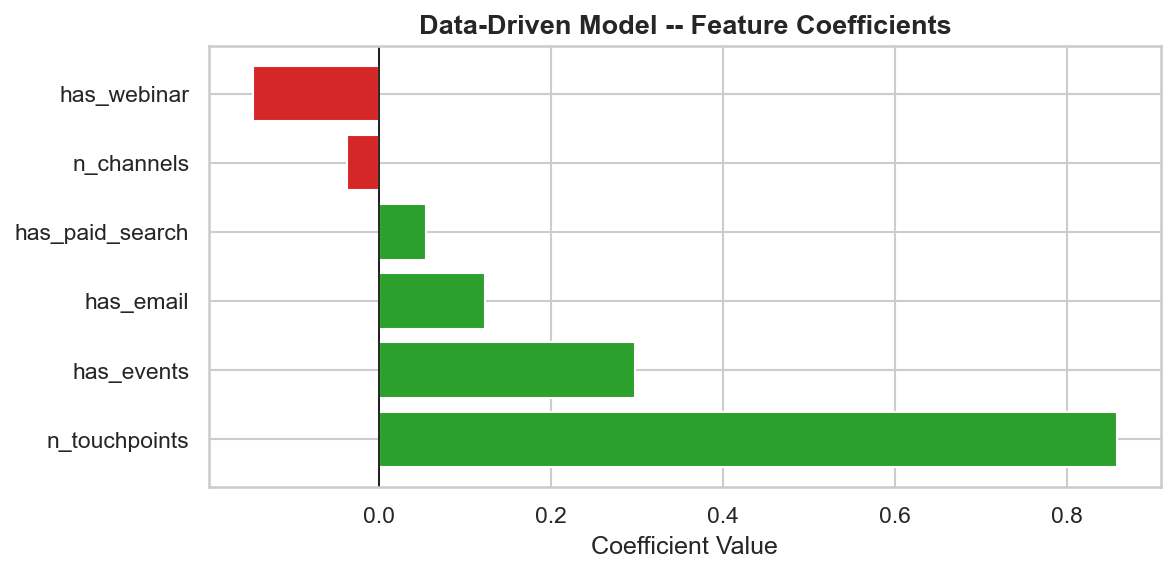

In [7]:
from sklearn.linear_model import LogisticRegression

all_tps = pd.read_sql_query(
    "SELECT contact_id, touchpoint_id, channel FROM touchpoints LIMIT 50000", conn)
opps = pd.read_sql_query(
    "SELECT c.contact_id, o.amount FROM contacts c"
    " JOIN opportunities o ON o.primary_contact_id=c.contact_id"
    " WHERE o.closed_won=1", conn)

cf = (all_tps.groupby("contact_id")
             .agg(n_touchpoints=("touchpoint_id","count"),
                  n_channels=("channel","nunique"),
                  has_paid_search=("channel", lambda x: int("Paid_Search" in x.values)),
                  has_events=("channel", lambda x: int("Events" in x.values)),
                  has_webinar=("channel", lambda x: int("Webinar" in x.values)),
                  has_email=("channel", lambda x: int("Email" in x.values)))
             .reset_index())
cf = cf.merge(opps[["contact_id"]].drop_duplicates().assign(converted=1),
              on="contact_id", how="left")
cf["converted"] = cf["converted"].fillna(0).astype(int)

feats = ["n_touchpoints","n_channels","has_paid_search","has_events","has_webinar","has_email"]
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(cf[feats].fillna(0), cf["converted"])

coef_df = pd.DataFrame({"feature": feats, "coefficient": lr.coef_[0]})
coef_df = coef_df.sort_values("coefficient", ascending=False)
print("=== Data-Driven Model -- Logistic Regression Coefficients ===")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2ca02c" if c >= 0 else "#d62728" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Data-Driven Model -- Feature Coefficients", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("visuals/03_data_driven_coefs.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("visuals/03_data_driven_coefs.png"))


## 7. Model Recommendation

In [8]:
print("=== When to Use Which Attribution Model ===\n")
recs = {
    "First Touch":    "Brand awareness measurement; credits SEO/awareness channels fully.",
    "Last Touch":     "Sales-led orgs; useful when SDR activity dominates the close.",
    "Linear":         "Balanced baseline; penalises high-volume low-value channels.",
    "Time Decay":     "Recommended default for nurture-heavy funnels (7-day half-life).",
    "Position-Based": "When both awareness AND conversion touchpoints matter.",
    "Data-Driven":    "Most rigorous for large datasets (>50K); use for budget planning.",
}
for model, rec in recs.items():
    print(f"  {model:20s}: {rec}")
print("\n-> RECOMMENDATION: Use Time Decay as primary model.")
print("   Supplement with Data-Driven for annual budget allocation.")


=== When to Use Which Attribution Model ===

  First Touch         : Brand awareness measurement; credits SEO/awareness channels fully.
  Last Touch          : Sales-led orgs; useful when SDR activity dominates the close.
  Linear              : Balanced baseline; penalises high-volume low-value channels.
  Time Decay          : Recommended default for nurture-heavy funnels (7-day half-life).
  Position-Based      : When both awareness AND conversion touchpoints matter.
  Data-Driven         : Most rigorous for large datasets (>50K); use for budget planning.

-> RECOMMENDATION: Use Time Decay as primary model.
   Supplement with Data-Driven for annual budget allocation.


In [9]:
conn.close()
print("Done.")


Done.
